In [13]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
d=pd.read_csv(r"C:\Users\sivas\Downloads\india_weather_100cities_clean.csv")
d

,city,latitude,longitude,init_time,timepoint_hr,temperature_c,cloud_cover,lifted_index,precipitation_type,precipitation_amount,relative_humidity,wind_direction,wind_speed,weather
0,Mumbai,19.076,72.877,2026-03-29 12:00:00,3,29.0,1,-4.0,none,0,65,NW,3.0,clearnight
1,Mumbai,19.076,72.877,2026-03-29 12:00:00,6,28.0,1,-1.0,none,0,68,NW,3.0,clearnight
2,Mumbai,19.076,72.877,2026-03-29 12:00:00,9,27.0,1,-1.0,none,0,65,N,3.0,clearnight
3,Mumbai,19.076,72.877,2026-03-29 12:00:00,12,27.0,1,-1.0,none,0,71,N,2.0,clearnight
4,Mumbai,19.076,72.877,2026-03-29 12:00:00,15,28.0,1,-4.0,none,0,60,N,2.0,clearday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6587,Panaji,15.496,73.828,2026-03-29 12:00:00,180,23.0,1,-1.0,none,0,95,N,2.0,humidnight
6588,Panaji,15.496,73.828,2026-03-29 12:00:00,183,28.0,1,-1.0,none,0,62,N,3.0,clearday
6589,Panaji,15.496,73.828,2026-03-29 12:00:00,186,33.0,1,-1.0,none,-1,62,W,3.0,tsday
6590,Panaji,15.496,73.828,2026-03-29 12:00:00,189,33.0,1,2.0,none,1,25,W,3.0,clearday


In [3]:
d.info()

<class 'pandas.DataFrame'>
RangeIndex: 6592 entries, 0 to 6591
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   city                  6592 non-null   str    
 1   latitude              6592 non-null   float64
 2   longitude             6592 non-null   float64
 3   init_time             6592 non-null   str    
 4   timepoint_hr          6592 non-null   int64  
 5   temperature_c         6592 non-null   float64
 6   cloud_cover           6592 non-null   int64  
 7   lifted_index          6592 non-null   float64
 8   precipitation_type    6592 non-null   str    
 9   precipitation_amount  6592 non-null   int64  
 10  relative_humidity     6592 non-null   int64  
 11  wind_direction        6592 non-null   str    
 12  wind_speed            6592 non-null   float64
 13  weather               6592 non-null   str    
dtypes: float64(5), int64(4), str(5)
memory usage: 721.1 KB


In [4]:
from sklearn.preprocessing import LabelEncoder

In [5]:
l=LabelEncoder()
d["weather"]=l.fit_transform(d["weather"])
d["weather"]

0        1
1        1
2        1
3        1
4        0
        ..
6587     5
6588     0
6589    20
6590     0
6591     0
Name: weather, Length: 6592, dtype: int64

In [6]:
w=d[["city","latitude","longitude"]].drop_duplicates()
w

,city,latitude,longitude
0,Mumbai,19.076,72.877
64,Delhi,28.614,77.209
128,Bangalore,12.972,77.595
192,Hyderabad,17.385,78.487
256,Ahmedabad,23.023,72.571
...,...,...,...
6272,Shillong,25.578,91.883
6336,Aizawl,23.728,92.718
6400,Itanagar,27.084,93.605
6464,Agartala,23.831,91.287


In [10]:
from sklearn.cluster import DBSCAN

In [11]:
coords=w[["latitude","longitude"]].values
db=DBSCAN(eps=2,min_samples=4)
label = db.fit_predict(coords)

w["cluster"]=label
w

,city,latitude,longitude,cluster
0,Mumbai,19.076,72.877,0
64,Delhi,28.614,77.209,1
128,Bangalore,12.972,77.595,2
192,Hyderabad,17.385,78.487,0
256,Ahmedabad,23.023,72.571,3
...,...,...,...,...
6272,Shillong,25.578,91.883,-1
6336,Aizawl,23.728,92.718,-1
6400,Itanagar,27.084,93.605,-1
6464,Agartala,23.831,91.287,-1


In [12]:
w["cluster"].value_counts()

cluster
 1    22
 0    21
-1    18
 2    11
 4    10
 3     6
 7     6
 6     5
 5     4
Name: count, dtype: int64

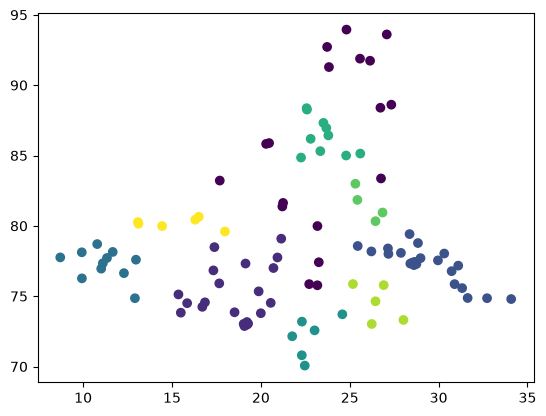

In [15]:
plt.scatter(w.iloc[:,1],w.iloc[:,2],c=label)
plt.show()

In [16]:
w1=d[["city","weather","temperature_c"]]
w1=pd.DataFrame(w1)
w1=w1.drop_duplicates()
w1

,city,weather,temperature_c
0,Mumbai,1,29.0
1,Mumbai,1,28.0
2,Mumbai,1,27.0
4,Mumbai,0,28.0
5,Mumbai,20,32.0
...,...,...,...
6574,Panaji,12,33.0
6582,Panaji,16,33.0
6587,Panaji,5,23.0
6588,Panaji,0,28.0


In [17]:
from sklearn.cluster import DBSCAN

In [19]:
coords1=w1[["weather","temperature_c"]].values

dbs=DBSCAN(eps=2,min_samples=3)
label_1=db.fit_predict(coords1)
w1["cluster"] =label_1
w1

,city,weather,temperature_c,cluster
0,Mumbai,1,29.0,0
1,Mumbai,1,28.0,0
2,Mumbai,1,27.0,0
4,Mumbai,0,28.0,0
5,Mumbai,20,32.0,1
...,...,...,...,...
6574,Panaji,12,33.0,1
6582,Panaji,16,33.0,1
6587,Panaji,5,23.0,0
6588,Panaji,0,28.0,0


In [20]:
w1["cluster"].value_counts()

cluster
 0    2703
 1    2089
 3       9
 2       4
-1       4
Name: count, dtype: int64

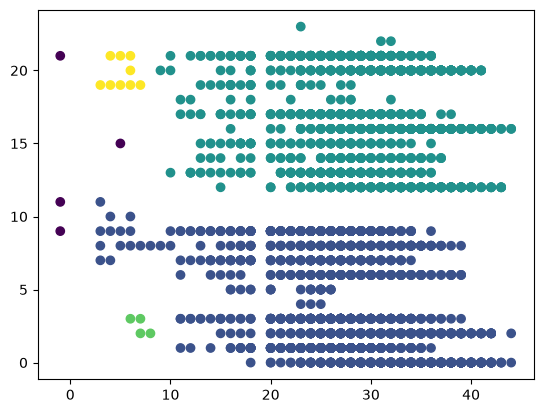

In [21]:
plt.scatter(w1.iloc[:,2],w1.iloc[:,1],c=label_1)
plt.show()